In [18]:
import pandas as pd

sca_path = pd.read_csv('raw_data/UIB_SCA_Daily_25Year_with500mscale.csv')
sca_path.head()

,date,sca_km2
0,2000-02-24,0.000000
1,2000-02-25,0.000000
2,2000-02-26,69613.623667
3,2000-02-27,13529.596444
4,2000-02-28,35590.105541


<Axes: >

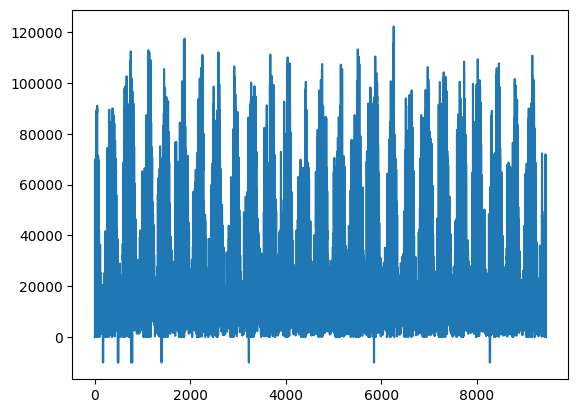

In [19]:
sca_path["sca_km2"].plot()


In [22]:
import numpy as np
sca_path['sca_km2']= sca_path['sca_km2'].replace(-9999, np.nan)
sca_path['sca_km2']= sca_path['sca_km2'].interpolate(method= 'linear')


<Axes: >

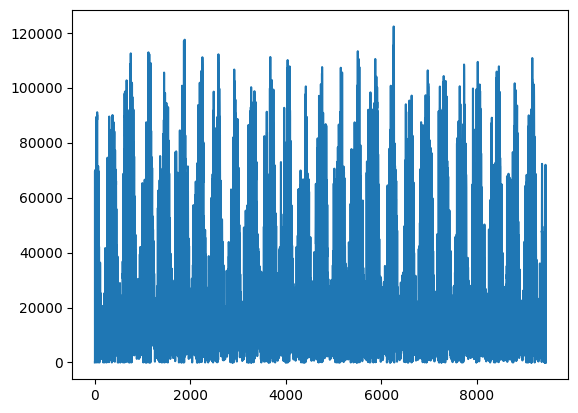

In [23]:
sca_path['sca_km2'].plot()

In [24]:
sca_path.describe()

,sca_km2
count,9443.000000
mean,28015.502334
std,25153.228230
min,0.000000
25%,7906.162275
50%,20389.136792
75%,41810.774657
max,122256.212024


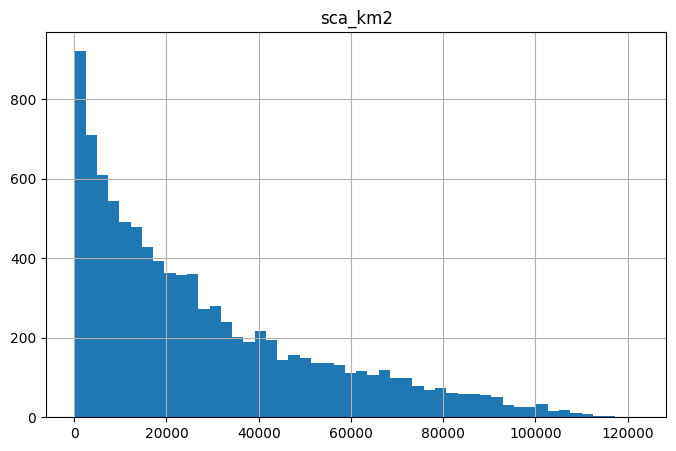

In [25]:
import matplotlib.pyplot as plt
sca_path.hist(bins=50, figsize=(8,5))
plt.show()

tail heavy data

In [26]:
sca_path['date']=pd.to_datetime(sca_path['date'])

sca_monthly= sca_path.set_index('date').resample('ME').mean()

<Axes: xlabel='date'>

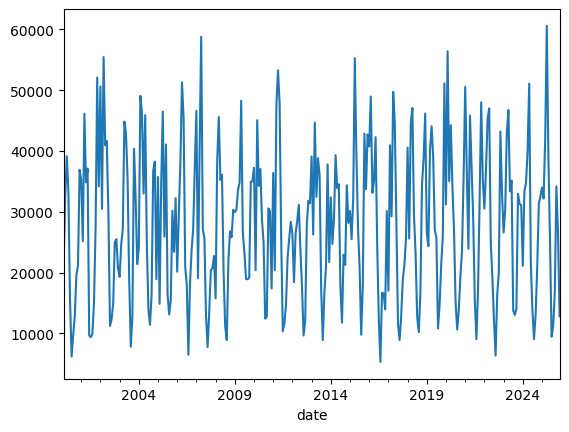

In [27]:
sca_monthly['sca_km2'].plot()

In [28]:
sca_monthly.head(20)

,sca_km2
date,
2000-02-29,20719.275466
2000-03-31,32510.026998
2000-04-30,39144.713419
2000-05-31,33300.144655
2000-06-30,15695.091988
2000-07-31,6188.434963
2000-08-31,9724.768803
2000-09-30,12888.810599
2000-10-31,19583.623736


In [29]:
sca_monthly.to_csv('sca_monthly_final.csv', index=True)

precipitation


In [8]:
precip= pd.read_csv('raw_data/precipitation_daily_till2025.csv')
precip.head()

,date,precip_mm_hr
0,2000-06-01,0.013637
1,2000-06-02,0.035425
2,2000-06-03,0.115409
3,2000-06-04,0.030344
4,2000-06-05,0.009008


<Axes: >

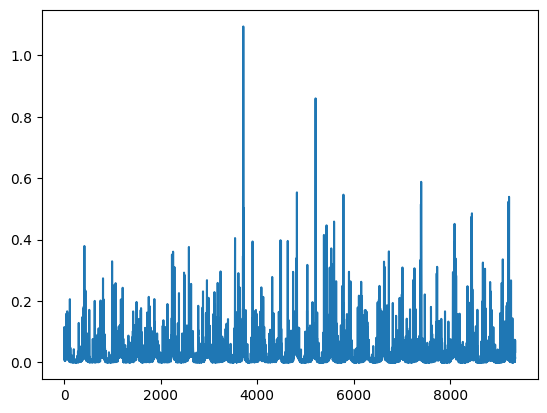

In [9]:
precip['precip_mm_hr'].plot()

In [10]:
precip.describe()

,precip_mm_hr
count,9345.000000
mean,0.029516
std,0.051620
min,0.000007
25%,0.002638
50%,0.011940
75%,0.035232
max,1.094153


In [11]:
import datetime


precip['date']= pd.to_datetime(precip['date'])
precip_monthly= precip.set_index('date').resample('ME').sum()

In [12]:
precip_monthly.head()

,precip_mm_hr
date,
2000-06-30,1.081265
2000-07-31,2.074423
2000-08-31,1.208544
2000-09-30,0.857759
2000-10-31,0.231264


In [13]:
precip_monthly.to_csv('precip_monthly_final.csv')

radiation


In [14]:
radiation=pd.read_csv('raw_data/radiation.csv')
radiation.head()

,date,surface_net_solar_radiation_J/m²
0,2000-01-01,1.010814e+08
1,2000-01-02,1.028880e+08
2,2000-01-03,1.043017e+08
3,2000-01-04,1.065605e+08
4,2000-01-05,1.074323e+08


<Axes: >

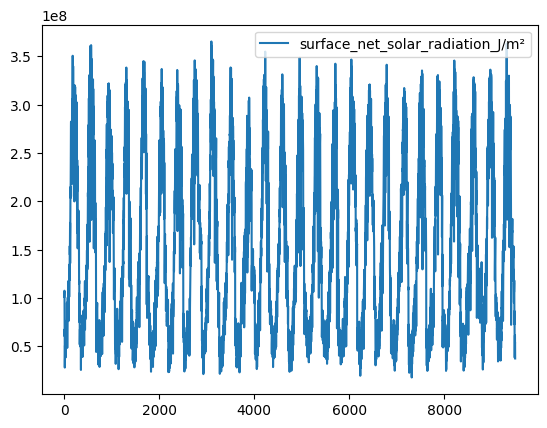

In [15]:
radiation.plot()

In [16]:
radiation['MJ/m2']=radiation['surface_net_solar_radiation_J/m²']/1e6

In [17]:
radiation.head()

,date,surface_net_solar_radiation_J/m²,MJ/m2
0,2000-01-01,1.010814e+08,101.081403
1,2000-01-02,1.028880e+08,102.887973
2,2000-01-03,1.043017e+08,104.301699
3,2000-01-04,1.065605e+08,106.560510
4,2000-01-05,1.074323e+08,107.432259


In [18]:
radiation['date']= pd.to_datetime(radiation['date'])
radiation_monthly= radiation.set_index('date').resample('ME').sum()

In [19]:
radiation_monthly.head()

,surface_net_solar_radiation_J/m²,MJ/m2
date,,
2000-01-31,1.923235e+09,1923.234974
2000-02-29,1.968442e+09,1968.442271
2000-03-31,2.725839e+09,2725.839011
2000-04-30,3.675053e+09,3675.053095
2000-05-31,6.963324e+09,6963.324171


In [20]:
radiation_monthlymj=radiation_monthly.drop('surface_net_solar_radiation_J/m²',axis=1)

In [21]:
radiation_monthlymj.to_csv('radiation_final.csv')

dewpoint_temp

In [22]:
dew=pd.read_csv('raw_data/dewpoint_temp.csv')
dew.head()

,date,max_dew,mean_dew,min_dew
0,2000-01-01,253.985364,248.536035,243.221182
1,2000-01-02,254.275342,248.673787,243.299982
2,2000-01-03,254.318691,248.248584,242.292849
3,2000-01-04,253.546635,247.322608,241.245679
4,2000-01-05,252.993135,247.235463,241.202744


<Axes: >

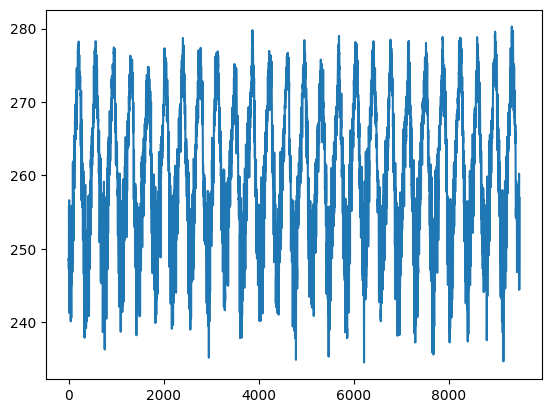

In [23]:
dew['mean_dew'].plot()

In [24]:
dew['date']=pd.to_datetime(dew['date'])
dew_monthly=dew.set_index('date').resample('ME').mean()

In [25]:
dew_monthly.head()

,max_dew,mean_dew,min_dew
date,,,
2000-01-31,252.546937,248.830175,244.081793
2000-02-29,250.487436,246.837709,242.039422
2000-03-31,255.653451,251.756290,246.152659
2000-04-30,262.307128,257.917184,251.759042
2000-05-31,269.000671,265.283957,260.299567


In [26]:
dew_monthly.to_csv('dewpoint_temp_final.csv')

NDVI

In [27]:
ndvi= pd.read_csv('raw_data/NDVI_16day_combined.csv')
ndvi.head()

,NDVI,date
0,0.378932,2000-02-18
1,0.402340,2000-03-05
2,0.394584,2000-03-21
3,0.378874,2000-04-06
4,0.308566,2000-04-22


In [28]:
ndvi['date']= pd.to_datetime(ndvi['date'])
ndvi_monthly= ndvi.set_index('date').resample('ME').mean()

In [29]:
ndvi_monthly.head()

,NDVI
date,
2000-02-29,0.378932
2000-03-31,0.398462
2000-04-30,0.343720
2000-05-31,0.171840
2000-06-30,0.167895


In [30]:
ndvi_monthly.to_csv('ndvi_final.csv')

temp

In [31]:
import pandas as pd

temp= pd.read_csv('raw_data/temperature2000_2025.csv')
temp['date']= pd.to_datetime(temp['date'])
temp_monthly= temp.set_index('date').resample('ME').mean()

FileNotFoundError: [Errno 2] No such file or directory: 'raw_data/temperature2000_2025.csv'

In [ ]:
tempd=datesync(temp_monthly)

In [32]:
temp_monthly.to_csv('temperature_final.csv')

NameError: name 'temp_monthly' is not defined

runoff


In [6]:
runoff1= pd.read_csv('raw_data/runoff.csv')
runoff1['date']= pd.to_datetime(runoff1['date'])
runoff_monthly= runoff1.set_index('date').resample('ME').sum()

<Axes: xlabel='date'>

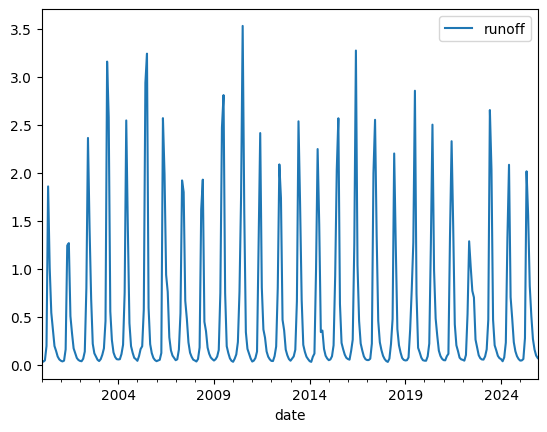

In [7]:
runoff_monthly.plot()

In [8]:
runoff_monthly.to_csv('runoff_final.csv')

In [36]:
runoff_aggr= pd.read_csv('raw_data/runoff_monthlyagrr.csv')
runoff_aggr['date']= pd.to_datetime(runoff_aggr['date'])
runoff_monthlyaggr= runoff_aggr.set_index('date').resample('ME').sum()

<Axes: xlabel='date'>

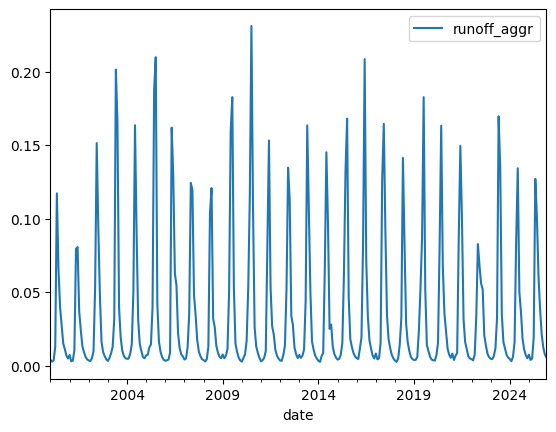

In [37]:
runoff_monthlyaggr.plot()

In [38]:
import pandas as pd
df= pd.read_csv('final_data_physics_baseline/ndvi_final.csv')
dfdew= pd.read_csv('final_data_physics_baseline/dewpoint_temp_final.csv')
dfrad= pd.read_csv('final_data_physics_baseline/radiation_final.csv')

display(df.head(), dfdew.head(), dfrad.head())

,date,NDVI
0,2000-06-30,0.167895
1,2000-07-31,0.214835
2,2000-08-31,0.171795
3,2000-09-30,0.148384
4,2000-10-31,0.113129


,date,max_dew,mean_dew,min_dew
0,2000-06-30,273.145365,270.274111,266.516247
1,2000-07-31,277.756620,275.634907,273.364489
2,2000-08-31,276.114859,273.643363,270.775474
3,2000-09-30,269.951828,266.780844,262.967096
4,2000-10-31,263.168205,259.412862,254.854415


,date,MJ/m2
0,2000-06-30,8552.215167
1,2000-07-31,8945.476526
2,2000-08-31,8787.250911
3,2000-09-30,7687.016192
4,2000-10-31,5685.865842


In [39]:
def norm(dff, col):
        normalized_col = f'{col}_normalized'
        epsilon = 1e-10  # Very small number (0.0000000001)

        df[normalized_col]= (dff[col]-dff[col].min())/(dff[col].max()-dff[col].min())+ epsilon
        return df, dff[col].min()

In [40]:
norm(dfrad, 'MJ/m2')

(           date      NDVI  MJ/m2_normalized
 0    2000-06-30  0.167895          0.859456
 1    2000-07-31  0.214835          0.905239
 2    2000-08-31  0.171795          0.886819
 3    2000-09-30  0.148384          0.758731
 4    2000-10-31  0.113129          0.525759
 ..          ...       ...               ...
 301  2025-07-31  0.226520          0.866737
 302  2025-08-31  0.191359          0.828569
 303  2025-09-30  0.183518          0.749586
 304  2025-10-31  0.183481          0.418882
 305  2025-11-30  0.116770          0.386199
 
 [306 rows x 3 columns],
 np.float64(1169.768120458106))

In [41]:
norm(dfdew, 'mean_dew')

(           date      NDVI  MJ/m2_normalized  mean_dew_normalized
 0    2000-06-30  0.167895          0.859456             0.813767
 1    2000-07-31  0.214835          0.905239             0.980966
 2    2000-08-31  0.171795          0.886819             0.918851
 3    2000-09-30  0.148384          0.758731             0.704815
 4    2000-10-31  0.113129          0.525759             0.475014
 ..          ...       ...               ...                  ...
 301  2025-07-31  0.226520          0.866737             1.000000
 302  2025-08-31  0.191359          0.828569             0.948848
 303  2025-09-30  0.183518          0.749586             0.796637
 304  2025-10-31  0.183481          0.418882             0.452897
 305  2025-11-30  0.116770          0.386199             0.199935
 
 [306 rows x 4 columns],
 np.float64(244.182791665806))

In [42]:
norm(df, 'NDVI')

(           date      NDVI  MJ/m2_normalized  mean_dew_normalized  \
 0    2000-06-30  0.167895          0.859456             0.813767   
 1    2000-07-31  0.214835          0.905239             0.980966   
 2    2000-08-31  0.171795          0.886819             0.918851   
 3    2000-09-30  0.148384          0.758731             0.704815   
 4    2000-10-31  0.113129          0.525759             0.475014   
 ..          ...       ...               ...                  ...   
 301  2025-07-31  0.226520          0.866737             1.000000   
 302  2025-08-31  0.191359          0.828569             0.948848   
 303  2025-09-30  0.183518          0.749586             0.796637   
 304  2025-10-31  0.183481          0.418882             0.452897   
 305  2025-11-30  0.116770          0.386199             0.199935   
 
      NDVI_normalized  
 0           0.221072  
 1           0.317549  
 2           0.229089  
 3           0.180971  
 4           0.108510  
 ..               ...  
 3

In [43]:
df1=df.drop(columns= 'NDVI')

In [44]:
df1.to_csv('et_loss.csv', index=False)

In [45]:
df1['et_loss']= df['NDVI_normalized']*(1-df['mean_dew_normalized'])*df['MJ/m2_normalized']

In [46]:
df1.head()

,date,MJ/m2_normalized,mean_dew_normalized,NDVI_normalized,et_loss
0,2000-06-30,0.859456,0.813767,0.221072,0.035384
1,2000-07-31,0.905239,0.980966,0.317549,0.005471
2,2000-08-31,0.886819,0.918851,0.229089,0.016486
3,2000-09-30,0.758731,0.704815,0.180971,0.040531
4,2000-10-31,0.525759,0.475014,0.108510,0.029951


In [47]:
df2= df1.drop(columns=['NDVI_normalized','mean_dew_normalized','MJ/m2_normalized'])

In [48]:
row= df1.loc[df1['date'] == '2024-12-31']
print(row)

           date  MJ/m2_normalized  mean_dew_normalized  NDVI_normalized  \
294  2024-12-31          0.134114             0.079916     1.000000e-10   

          et_loss  
294  1.233962e-11  


In [49]:
df2.to_csv('et_loss.csv')

In [50]:
import pandas as pd
tempp=pd.read_csv('final_data_physics_baseline/temperature_final.csv')
tempp.head(15)


,date,max_temp,min_temp,temp_mean
0,2000-06-30,281.266866,269.659478,276.271130
1,2000-07-31,284.915298,275.573296,280.535170
2,2000-08-31,283.488984,272.957333,278.745643
3,2000-09-30,279.903865,268.115832,274.499669
4,2000-10-31,272.618625,260.208864,266.727686
5,2000-11-30,264.112653,253.791774,259.426247
6,2000-12-31,257.936524,248.963104,253.821086
7,2001-01-31,256.138436,247.202888,251.748642
8,2001-02-28,258.805327,249.196524,254.358244
9,2001-03-31,262.328365,250.882313,256.947447


In [51]:
threshold=273
count= (tempp['temp_mean']> threshold).sum()
count

np.int64(93)

In [52]:
tempp['dd']=tempp['temp_mean'].apply(lambda t: max(t-273, 0))

In [53]:
threshold= 0
count= (tempp['dd']> threshold).sum()
count

np.int64(93)

In [54]:
tempp.head(30)

,date,max_temp,min_temp,temp_mean,dd
0,2000-06-30,281.266866,269.659478,276.271130,3.271130
1,2000-07-31,284.915298,275.573296,280.535170,7.535170
2,2000-08-31,283.488984,272.957333,278.745643,5.745643
3,2000-09-30,279.903865,268.115832,274.499669,1.499669
4,2000-10-31,272.618625,260.208864,266.727686,0.000000
5,2000-11-30,264.112653,253.791774,259.426247,0.000000
6,2000-12-31,257.936524,248.963104,253.821086,0.000000
7,2001-01-31,256.138436,247.202888,251.748642,0.000000
8,2001-02-28,258.805327,249.196524,254.358244,0.000000
9,2001-03-31,262.328365,250.882313,256.947447,0.000000


In [55]:
from utils import datesync
datesync(df=tempp)


,max_temp,min_temp,temp_mean,dd
date,,,,
2000-06-30,281.266866,269.659478,276.271130,3.271130
2000-07-31,284.915298,275.573296,280.535170,7.535170
2000-08-31,283.488984,272.957333,278.745643,5.745643
2000-09-30,279.903865,268.115832,274.499669,1.499669
2000-10-31,272.618625,260.208864,266.727686,0.000000
...,...,...,...,...
2025-07-31,286.324621,277.148619,282.033636,9.033636
2025-08-31,285.187829,275.210281,280.636221,7.636221
2025-09-30,282.045947,270.730974,276.943292,3.943292


In [56]:
dew= pd.read_csv('final_data_physics_baseline/dewpoint_temp_final.csv')
et = pd.read_csv('final_data_physics_baseline/et_loss.csv')
ndvi = pd.read_csv('final_data_physics_baseline/ndvi_final.csv')
precip= pd.read_csv('final_data_physics_baseline/precip_monthly_final.csv')
radiation = pd.read_csv('final_data_physics_baseline/radiation_final.csv')
sca = pd.read_csv('final_data_physics_baseline/sca_monthly_final.csv')


In [57]:

display(dew.head(), et.head(), ndvi.head(), precip.head(), radiation.head(), sca.head(), tempp.head())


,date,max_dew,mean_dew,min_dew
0,2000-06-30,273.145365,270.274111,266.516247
1,2000-07-31,277.756620,275.634907,273.364489
2,2000-08-31,276.114859,273.643363,270.775474
3,2000-09-30,269.951828,266.780844,262.967096
4,2000-10-31,263.168205,259.412862,254.854415


,Unnamed: 0,date,et_loss
0,0,2000-06-30,0.035384
1,1,2000-07-31,0.005471
2,2,2000-08-31,0.016486
3,3,2000-09-30,0.040531
4,4,2000-10-31,0.029951


,date,NDVI
0,2000-06-30,0.167895
1,2000-07-31,0.214835
2,2000-08-31,0.171795
3,2000-09-30,0.148384
4,2000-10-31,0.113129


,date,precip_mm_hr
0,2000-06-30,1.081265
1,2000-07-31,2.074423
2,2000-08-31,1.208544
3,2000-09-30,0.857759
4,2000-10-31,0.231264


,date,MJ/m2
0,2000-06-30,8552.215167
1,2000-07-31,8945.476526
2,2000-08-31,8787.250911
3,2000-09-30,7687.016192
4,2000-10-31,5685.865842


,date,sca_km2
0,2000-06-30,15695.091988
1,2000-07-31,6188.434963
2,2000-08-31,10114.130241
3,2000-09-30,12888.810599
4,2000-10-31,19583.623736


,date,max_temp,min_temp,temp_mean,dd
0,2000-06-30,281.266866,269.659478,276.271130,3.271130
1,2000-07-31,284.915298,275.573296,280.535170,7.535170
2,2000-08-31,283.488984,272.957333,278.745643,5.745643
3,2000-09-30,279.903865,268.115832,274.499669,1.499669
4,2000-10-31,272.618625,260.208864,266.727686,0.000000


In [58]:
physics_base = pd.DataFrame()

physics_base['date'] = dew['date']

# Add multiple columns from different DataFrames
physics_base['dewpoint'] = dew['mean_dew']
physics_base['et_loss'] = et['et_loss']
physics_base['ndvi'] = ndvi['NDVI']
physics_base['precipitation'] = precip['precip_mm_hr']
physics_base['radiation'] = radiation['MJ/m2']
physics_base['sca'] = sca['sca_km2']
physics_base['dd'] = tempp['dd']
physics_base['temp'] = tempp['temp_mean']

In [10]:
runoff = pd.read_csv('runoff_final.csv')
runoff.head()

,date,runoff
0,2000-01-31,0.046517
1,2000-02-29,0.033367
2,2000-03-31,0.046674
3,2000-04-30,0.196312
4,2000-05-31,1.857505


In [11]:
physics_base.count()

NameError: name 'physics_base' is not defined

In [12]:
physics_base.to_csv('physics_basedate.csv')

NameError: name 'physics_base' is not defined

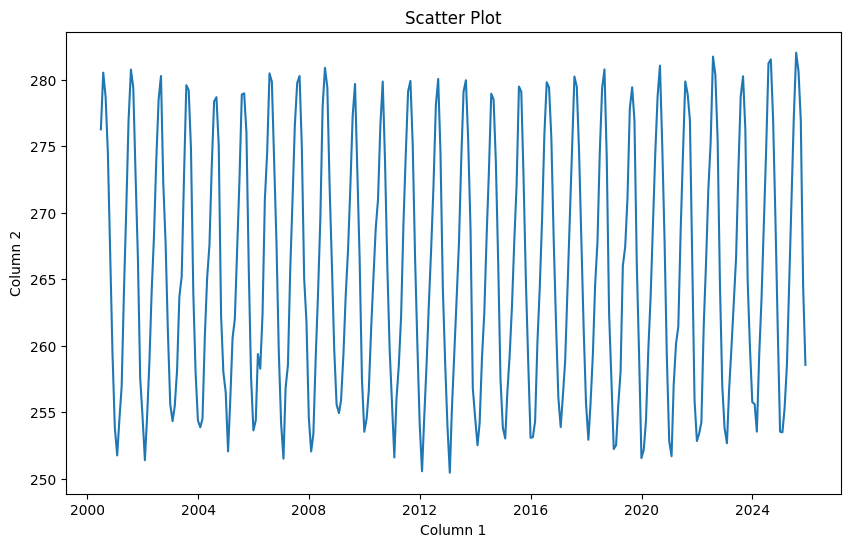

In [62]:
import pandas as pd
import matplotlib.pyplot as plt


# Scatter plot
plt.figure(figsize=(10, 6))
plt.plot(tempp['date'], tempp['temp_mean'])
plt.xlabel('Column 1')
plt.ylabel('Column 2')
plt.title('Scatter Plot')
plt.show()

# bias correction

In [13]:
# runoff ~5%
import pandas as pd
runoff= pd.read_csv('runoff_final.csv')
runoff

,date,runoff
0,2000-01-31,0.046517
1,2000-02-29,0.033367
2,2000-03-31,0.046674
3,2000-04-30,0.196312
4,2000-05-31,1.857505
...,...,...
307,2025-08-31,0.507926
308,2025-09-30,0.268507
309,2025-10-31,0.159146
310,2025-11-30,0.097332


In [14]:
runoff['runoff_corrected'] = runoff['runoff']*0.95

In [15]:
run = runoff.drop(columns= 'runoff')

In [16]:
run.head()

,date,runoff_corrected
0,2000-01-31,0.044192
1,2000-02-29,0.031699
2,2000-03-31,0.044341
3,2000-04-30,0.186496
4,2000-05-31,1.764630


In [17]:
run.to_csv('runoff_final.csv')

In [65]:
phy = pd.read_csv('final_data_physics_baseline/physics_basedate.csv')

In [66]:
phy.head()

,Unnamed: 0,date,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff
0,0,2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,0.0,253.924696,1.009778
1,1,2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,0.0,251.865719,0.543038
2,2,2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,0.0,256.913569,0.373700
3,3,2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,0.0,263.094486,0.196165
4,4,2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.0,271.551964,0.145426


In [67]:
phy.drop(columns='runoff')

,Unnamed: 0,date,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp
0,0,2000-06-30,270.274111,3.538449e-02,0.167895,1.081265,8552.215167,15695.091988,0.000000,253.924696
1,1,2000-07-31,275.634907,5.471431e-03,0.214835,2.074423,8945.476526,6188.434963,0.000000,251.865719
2,2,2000-08-31,273.643363,1.648614e-02,0.171795,1.208544,8787.250911,10114.130241,0.000000,256.913569
3,3,2000-09-30,266.780844,4.053131e-02,0.148384,0.857759,7687.016192,12888.810599,0.000000,263.094486
4,4,2000-10-31,259.412862,2.995059e-02,0.113129,0.231264,5685.865842,19583.623736,0.000000,271.551964
...,...,...,...,...,...,...,...,...,...,...
301,301,2025-07-31,276.245179,2.960460e-11,0.226520,2.587007,8614.751440,9439.384406,0.000000,255.264012
302,302,2025-08-31,274.605137,1.141355e-02,0.191359,3.429811,8286.906126,11256.247468,0.000000,258.528594
303,303,2025-09-30,269.724878,3.859465e-02,0.183518,0.934844,7608.462356,16691.511776,0.000000,264.581760
304,304,2025-10-31,258.703766,5.800479e-02,0.183481,0.750958,4767.830711,34178.031966,0.000000,271.044402


In [68]:
phy['runoff']= runoff['runoff_corrected']

In [69]:
phy

,Unnamed: 0,date,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff
0,0,2000-06-30,270.274111,3.538449e-02,0.167895,1.081265,8552.215167,15695.091988,0.000000,253.924696,0.959289
1,1,2000-07-31,275.634907,5.471431e-03,0.214835,2.074423,8945.476526,6188.434963,0.000000,251.865719,0.515886
2,2,2000-08-31,273.643363,1.648614e-02,0.171795,1.208544,8787.250911,10114.130241,0.000000,256.913569,0.355015
3,3,2000-09-30,266.780844,4.053131e-02,0.148384,0.857759,7687.016192,12888.810599,0.000000,263.094486,0.186357
4,4,2000-10-31,259.412862,2.995059e-02,0.113129,0.231264,5685.865842,19583.623736,0.000000,271.551964,0.138155
...,...,...,...,...,...,...,...,...,...,...,...
301,301,2025-07-31,276.245179,2.960460e-11,0.226520,2.587007,8614.751440,9439.384406,0.000000,255.264012,0.780349
302,302,2025-08-31,274.605137,1.141355e-02,0.191359,3.429811,8286.906126,11256.247468,0.000000,258.528594,0.482529
303,303,2025-09-30,269.724878,3.859465e-02,0.183518,0.934844,7608.462356,16691.511776,0.000000,264.581760,0.255081
304,304,2025-10-31,258.703766,5.800479e-02,0.183481,0.750958,4767.830711,34178.031966,0.000000,271.044402,0.151189


In [70]:
tempp= pd.read_csv('final_data_physics_baseline/temperature_final.csv')

In [71]:
tempp.head()

,date,max_temp,min_temp,temp_mean
0,2000-06-30,281.266866,269.659478,276.271130
1,2000-07-31,284.915298,275.573296,280.535170
2,2000-08-31,283.488984,272.957333,278.745643
3,2000-09-30,279.903865,268.115832,274.499669
4,2000-10-31,272.618625,260.208864,266.727686


In [72]:
tempp['max_temp'] = tempp['max_temp'] + 2
tempp['min_temp'] = tempp['min_temp'] + 2
tempp['mean_temp'] = tempp['temp_mean'] + 2

In [73]:
phy['temp']= tempp['mean_temp']

In [74]:
phy.head()

,Unnamed: 0,date,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff
0,0,2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,0.0,278.271130,0.959289
1,1,2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,0.0,282.535170,0.515886
2,2,2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,0.0,280.745643,0.355015
3,3,2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,0.0,276.499669,0.186357
4,4,2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.0,268.727686,0.138155


In [75]:
tempp['dd'] = tempp['mean_temp'].apply(lambda x: max(x-273,0))

In [76]:
phy['dd']= tempp['dd']

In [77]:
phy.head()

,Unnamed: 0,date,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff
0,0,2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,5.271130,278.271130,0.959289
1,1,2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,9.535170,282.535170,0.515886
2,2,2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,7.745643,280.745643,0.355015
3,3,2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,3.499669,276.499669,0.186357
4,4,2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.000000,268.727686,0.138155


In [78]:
phy.to_csv('phy_final_corrected_data.csv')

In [79]:
runoff= pd.read_csv('final_data_physics_baseline/runoff_final.csv')
runoff.head()

,Unnamed: 0,date,runoff_corrected
0,0,2000-06-30,0.959289
1,1,2000-07-31,0.515886
2,2,2000-08-31,0.355015
3,3,2000-09-30,0.186357
4,4,2000-10-31,0.138155


In [80]:
runoff['runoff_corrected'].map(lambda x: x*165000*1000000)

0      1.582827e+11
1      8.512119e+10
2      5.857747e+10
3      3.074887e+10
4      2.279557e+10
           ...     
301    1.287576e+11
302    7.961737e+10
303    4.208840e+10
304    2.494614e+10
305    1.525673e+10
Name: runoff_corrected, Length: 306, dtype: float64

In [81]:
runoff.head()

,Unnamed: 0,date,runoff_corrected
0,0,2000-06-30,0.959289
1,1,2000-07-31,0.515886
2,2,2000-08-31,0.355015
3,3,2000-09-30,0.186357
4,4,2000-10-31,0.138155


In [30]:
sca= pd.read_csv('sca_monthly_final.csv')

In [31]:
sca['sca_m2']= sca['sca_km2'].map(lambda x: x*1000000)

In [37]:
sca.head()

,date,sca_km2,sca_m2
0,2000-02-29,20719.275466,2.071928e+10
1,2000-03-31,32510.026998,3.251003e+10
2,2000-04-30,39144.713419,3.914471e+10
3,2000-05-31,33300.144655,3.330014e+10
4,2000-06-30,15695.091988,1.569509e+10


In [38]:
sca.to_csv('sca_monthly_final.csv')

In [39]:
import pandas as pd
phy= pd.read_csv('sca_monthly_final.csv')

In [40]:
phy.head()

,Unnamed: 0,date,sca_km2,sca_m2
0,0,2000-02-29,20719.275466,2.071928e+10
1,1,2000-03-31,32510.026998,3.251003e+10
2,2,2000-04-30,39144.713419,3.914471e+10
3,3,2000-05-31,33300.144655,3.330014e+10
4,4,2000-06-30,15695.091988,1.569509e+10


In [41]:
phy['sca%'] = (phy['sca_km2']/phy['sca_km2'].max())*100

In [42]:
phy.head()

,Unnamed: 0,date,sca_km2,sca_m2,sca%
0,0,2000-02-29,20719.275466,2.071928e+10,34.203194
1,1,2000-03-31,32510.026998,3.251003e+10,53.667261
2,2,2000-04-30,39144.713419,3.914471e+10,64.619741
3,3,2000-05-31,33300.144655,3.330014e+10,54.971580
4,4,2000-06-30,15695.091988,1.569509e+10,25.909317


In [43]:
phy['date'] = pd.to_datetime(phy['date'])
monthly_avg = phy.groupby(phy['date'].dt.month)['sca%'].mean()
print(monthly_avg)

date
1     52.679875
2     49.755259
3     63.192125
4     71.283237
5     62.651898
6     43.499720
7     24.876384
8     16.833859
9     25.933106
10    43.514115
11    50.724111
12    50.338402
Name: sca%, dtype: float64


In [90]:
import pandas as pd
run= pd.read_csv('raw_data/runoff.csv')

In [91]:
run.head(
    
)

,date,runoff
0,2000-01-01,0.001715
1,2000-01-02,0.001724
2,2000-01-03,0.001713
3,2000-01-04,0.001651
4,2000-01-05,0.001600


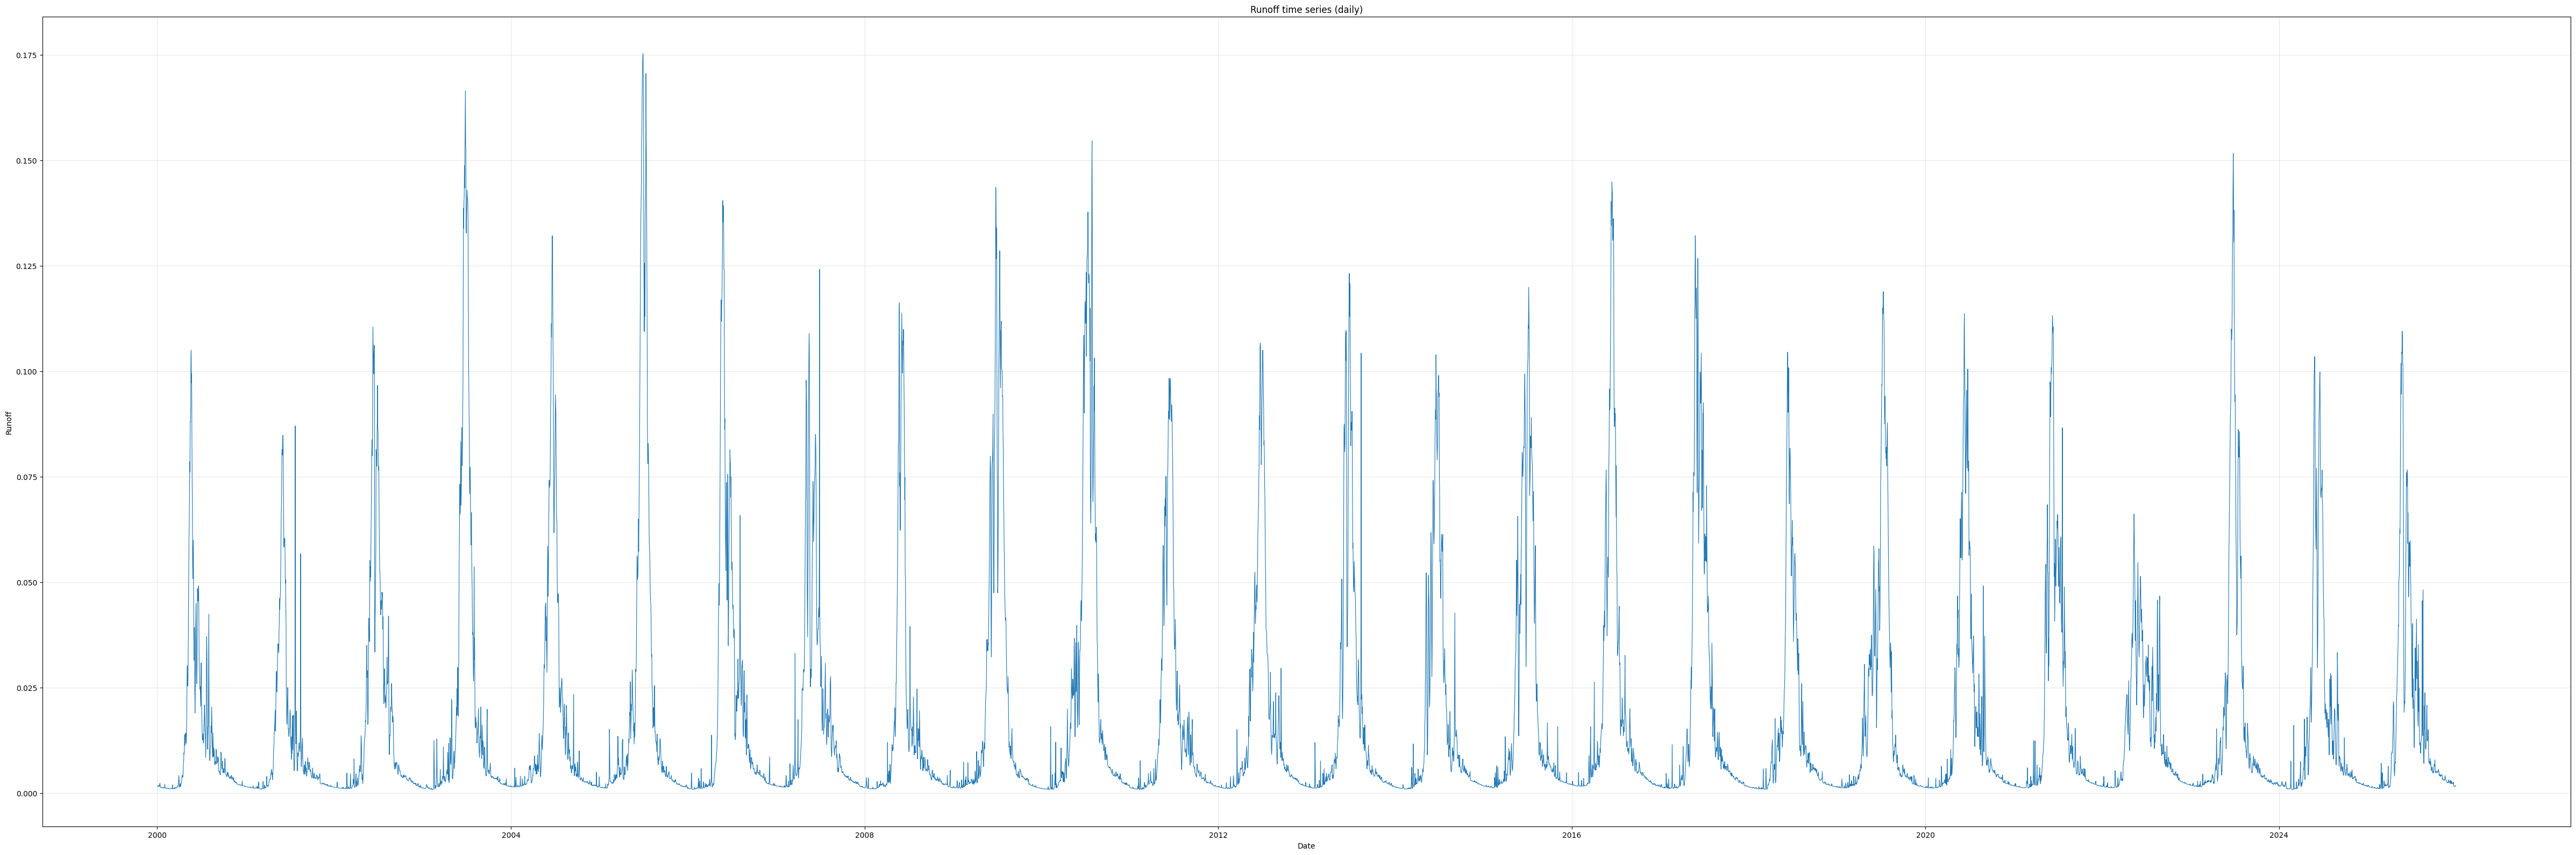

In [92]:
# ensure date column is datetime and plot the runoff time series from `run`
run['date'] = pd.to_datetime(run['date'])
import matplotlib.pyplot as plt
plt.figure(figsize=(48, 16))
plt.plot(run['date'], run['runoff'], lw=0.8)
plt.xlabel('Date')
plt.ylabel('Runoff')
plt.title('Runoff time series (daily)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [93]:
import pandas as pd
run= pd.read_csv('raw_data/runoff_monthlyagrr.csv')
run.head()

,date,runoff_aggr
0,2000-01-01,0.003801
1,2000-02-01,0.002739
2,2000-03-01,0.003547
3,2000-04-01,0.013005
4,2000-05-01,0.117175


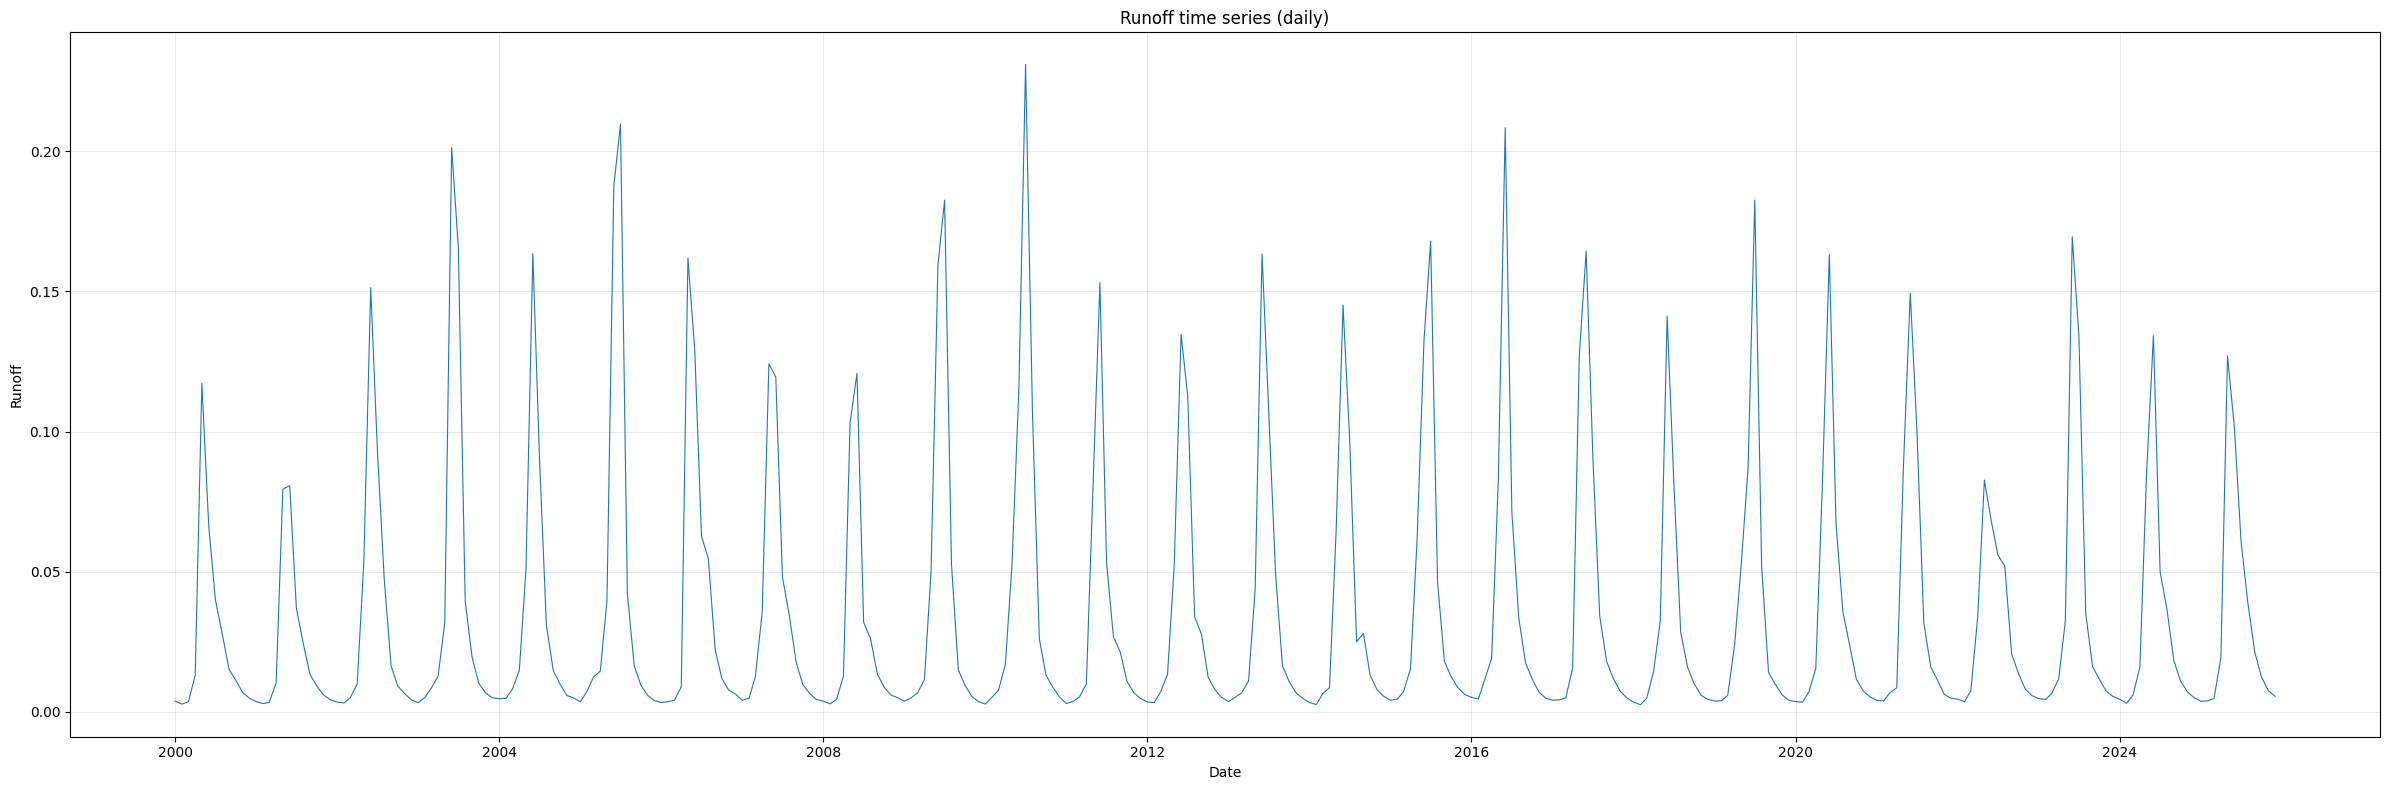

In [94]:

# ensure date column is datetime and plot the runoff time series from `run`
run['date'] = pd.to_datetime(run['date'])
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 8))
plt.plot(run['date'], run['runoff_aggr'], lw=0.8)
plt.xlabel('Date')
plt.ylabel('Runoff')
plt.title('Runoff time series (daily)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

FRESH CLEANUP OF FUP

In [2]:
import pandas as pd

In [3]:
runoff= pd.read_csv('final_data_physics_baseline/runoff_final.csv')
sca= pd.read_csv('final_data_physics_baseline/sca_monthly_final.csv')
et= pd.read_csv('final_data_physics_baseline/et_loss.csv')
precip= pd.read_csv('final_data_physics_baseline/precip_monthly_final.csv')
temp= pd.read_csv('final_data_physics_baseline/temperature_final.csv')


In [5]:
runoff.head(10)

,Unnamed: 0,date,runoff_corrected
0,0,2000-06-30,0.959289
1,1,2000-07-31,0.515886
2,2,2000-08-31,0.355015
3,3,2000-09-30,0.186357
4,4,2000-10-31,0.138155
5,5,2000-11-30,0.082439
6,6,2000-12-31,0.054509
7,7,2001-01-31,0.041160
8,8,2001-02-28,0.033957
9,9,2001-03-31,0.042010
